In [6]:
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.io import fits

import healpy as hp

import minimint

from galpy.orbit import Orbit

from survey import load_hvs_simulation_data, get_hvs_at_time, plot_initial_conditions, get_iso_data, load_footprint_mollweide_grid, \
    get_euclid_dr1_survey_cuts, get_hvs_survey_cuts, plot_galactic_distribution, plot_galactic_velocity
from helpers import convert_galactic_to_mollweide

plt.rcParams['figure.dpi'] = 300
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams["text.usetex"] = True

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import copy
from galpy.potential import MWPotential2014, ChandrasekharDynamicalFrictionForce

cdf = ChandrasekharDynamicalFrictionForce(
    GMs=1e11 * u.Msun, rhm=5.0 * u.kpc, dens=MWPotential2014
)
o_lmc = Orbit.from_name("LMC", ro=8.12*u.kpc, vo=220*u.km/u.s)

# increase halo mass by 50% so that LMC is bound
mwp = copy.deepcopy(MWPotential2014)
mwp[2] *= 1.5

end_time = -1e9 * u.yr
n_steps = 100
t_grid = np.linspace(
    0, end_time.to_value(u.yr),
    n_steps,
) * u.yr

# integrate the LMC orbit including dynamical friction.
o_lmc.integrate(t_grid, mwp + cdf, progressbar=True, method="rk4_c")

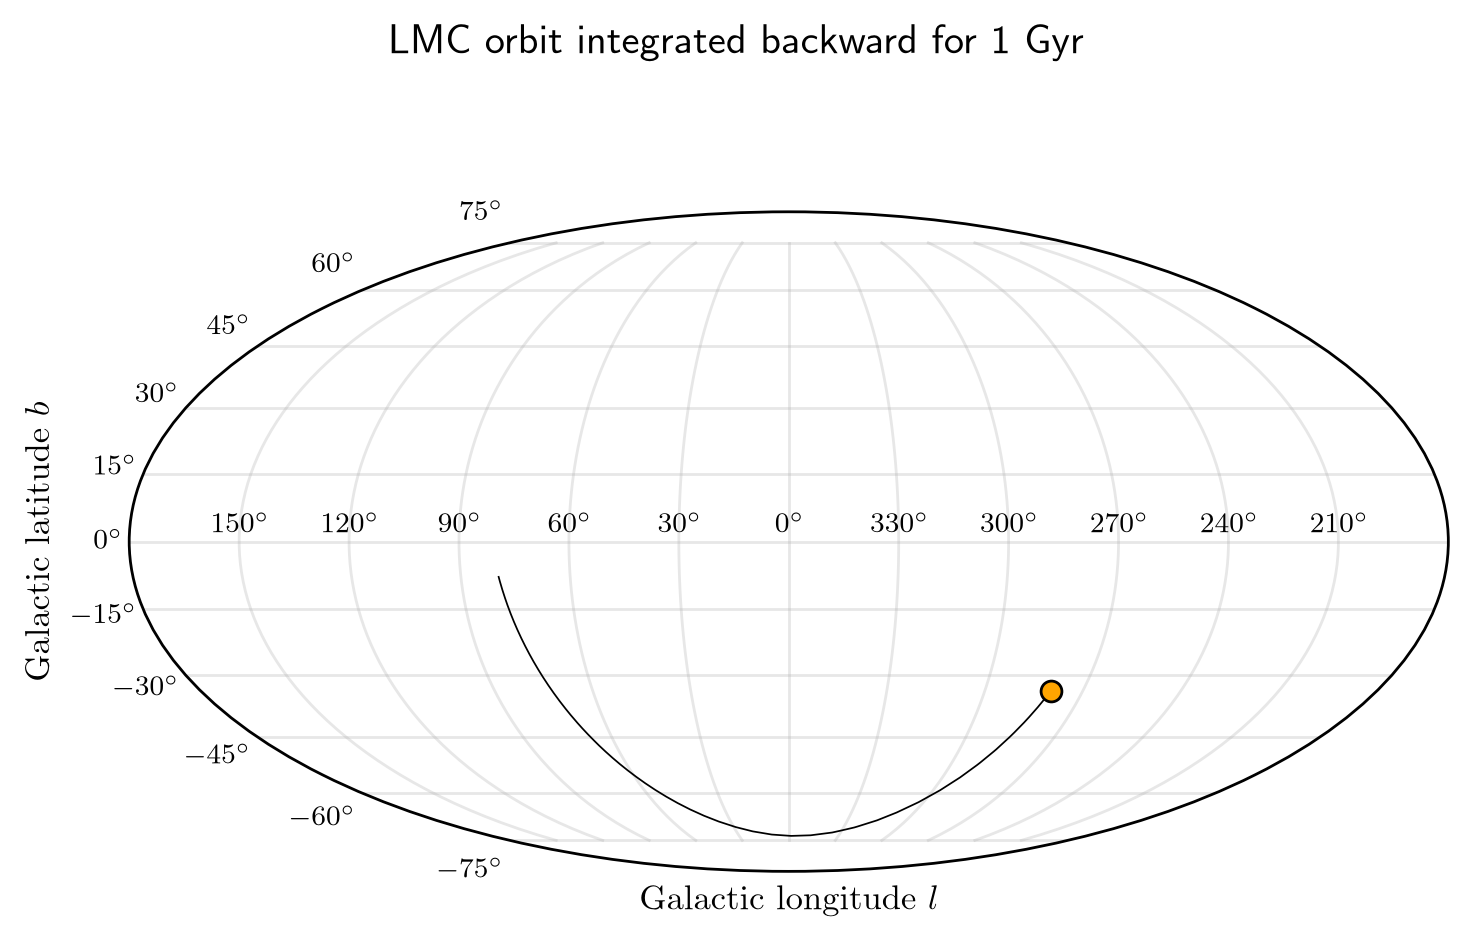

In [3]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection="mollweide")

l_lmc_orbit, b_lmc_orbit = convert_galactic_to_mollweide(o_lmc.ll(t_grid, quantity=True), o_lmc.bb(t_grid, quantity=True))
ax.plot(l_lmc_orbit, b_lmc_orbit, color='black', lw=0.5, label=r'$\rm integrated\ orbit$')
l_lmc_present, b_lmc_present = convert_galactic_to_mollweide(o_lmc.ll(0 * u.yr, quantity=True), o_lmc.bb(0 * u.yr, quantity=True))
ax.scatter(l_lmc_present, b_lmc_present, facecolor='orange', edgecolor='black', lw=0.8, ls='-', label=r'$\mathrm{LMC\ at\ present}$', zorder=2)

ax.set_xlabel(r"$\mathrm{Galactic\ longitude}\ l$")
ax.set_ylabel(r"$\mathrm{Galactic\ latitude}\ b$")
ax.grid(True, alpha=0.3)

tick_labels = [
    r"$150^\circ$", r"$120^\circ$", r"$90^\circ$",
    r"$60^\circ$", r"$30^\circ$", r"$0^\circ$",
    r"$330^\circ$", r"$300^\circ$", r"$270^\circ$",
    r"$240^\circ$", r"$210^\circ$",
]
ax.set_xticklabels(tick_labels, fontsize=8)
tick_labels = [r"$-75^\circ$", r"$-60^\circ$", r"$-45^\circ$", r"$-30^\circ$", r"$-15^\circ$", r"$0^\circ$", r"$15^\circ$", r"$30^\circ$", r"$45^\circ$", r"$60^\circ$", r"$75^\circ$"]
ax.set_yticklabels(tick_labels, fontsize=8)
fig.suptitle('LMC orbit integrated backward for 1 Gyr')

plt.tight_layout()
plt.show()

/var/folders/bd/xtg40qw103nbkl9ft_z7zhf40000gn/T/ipykernel_12235/1691055542.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



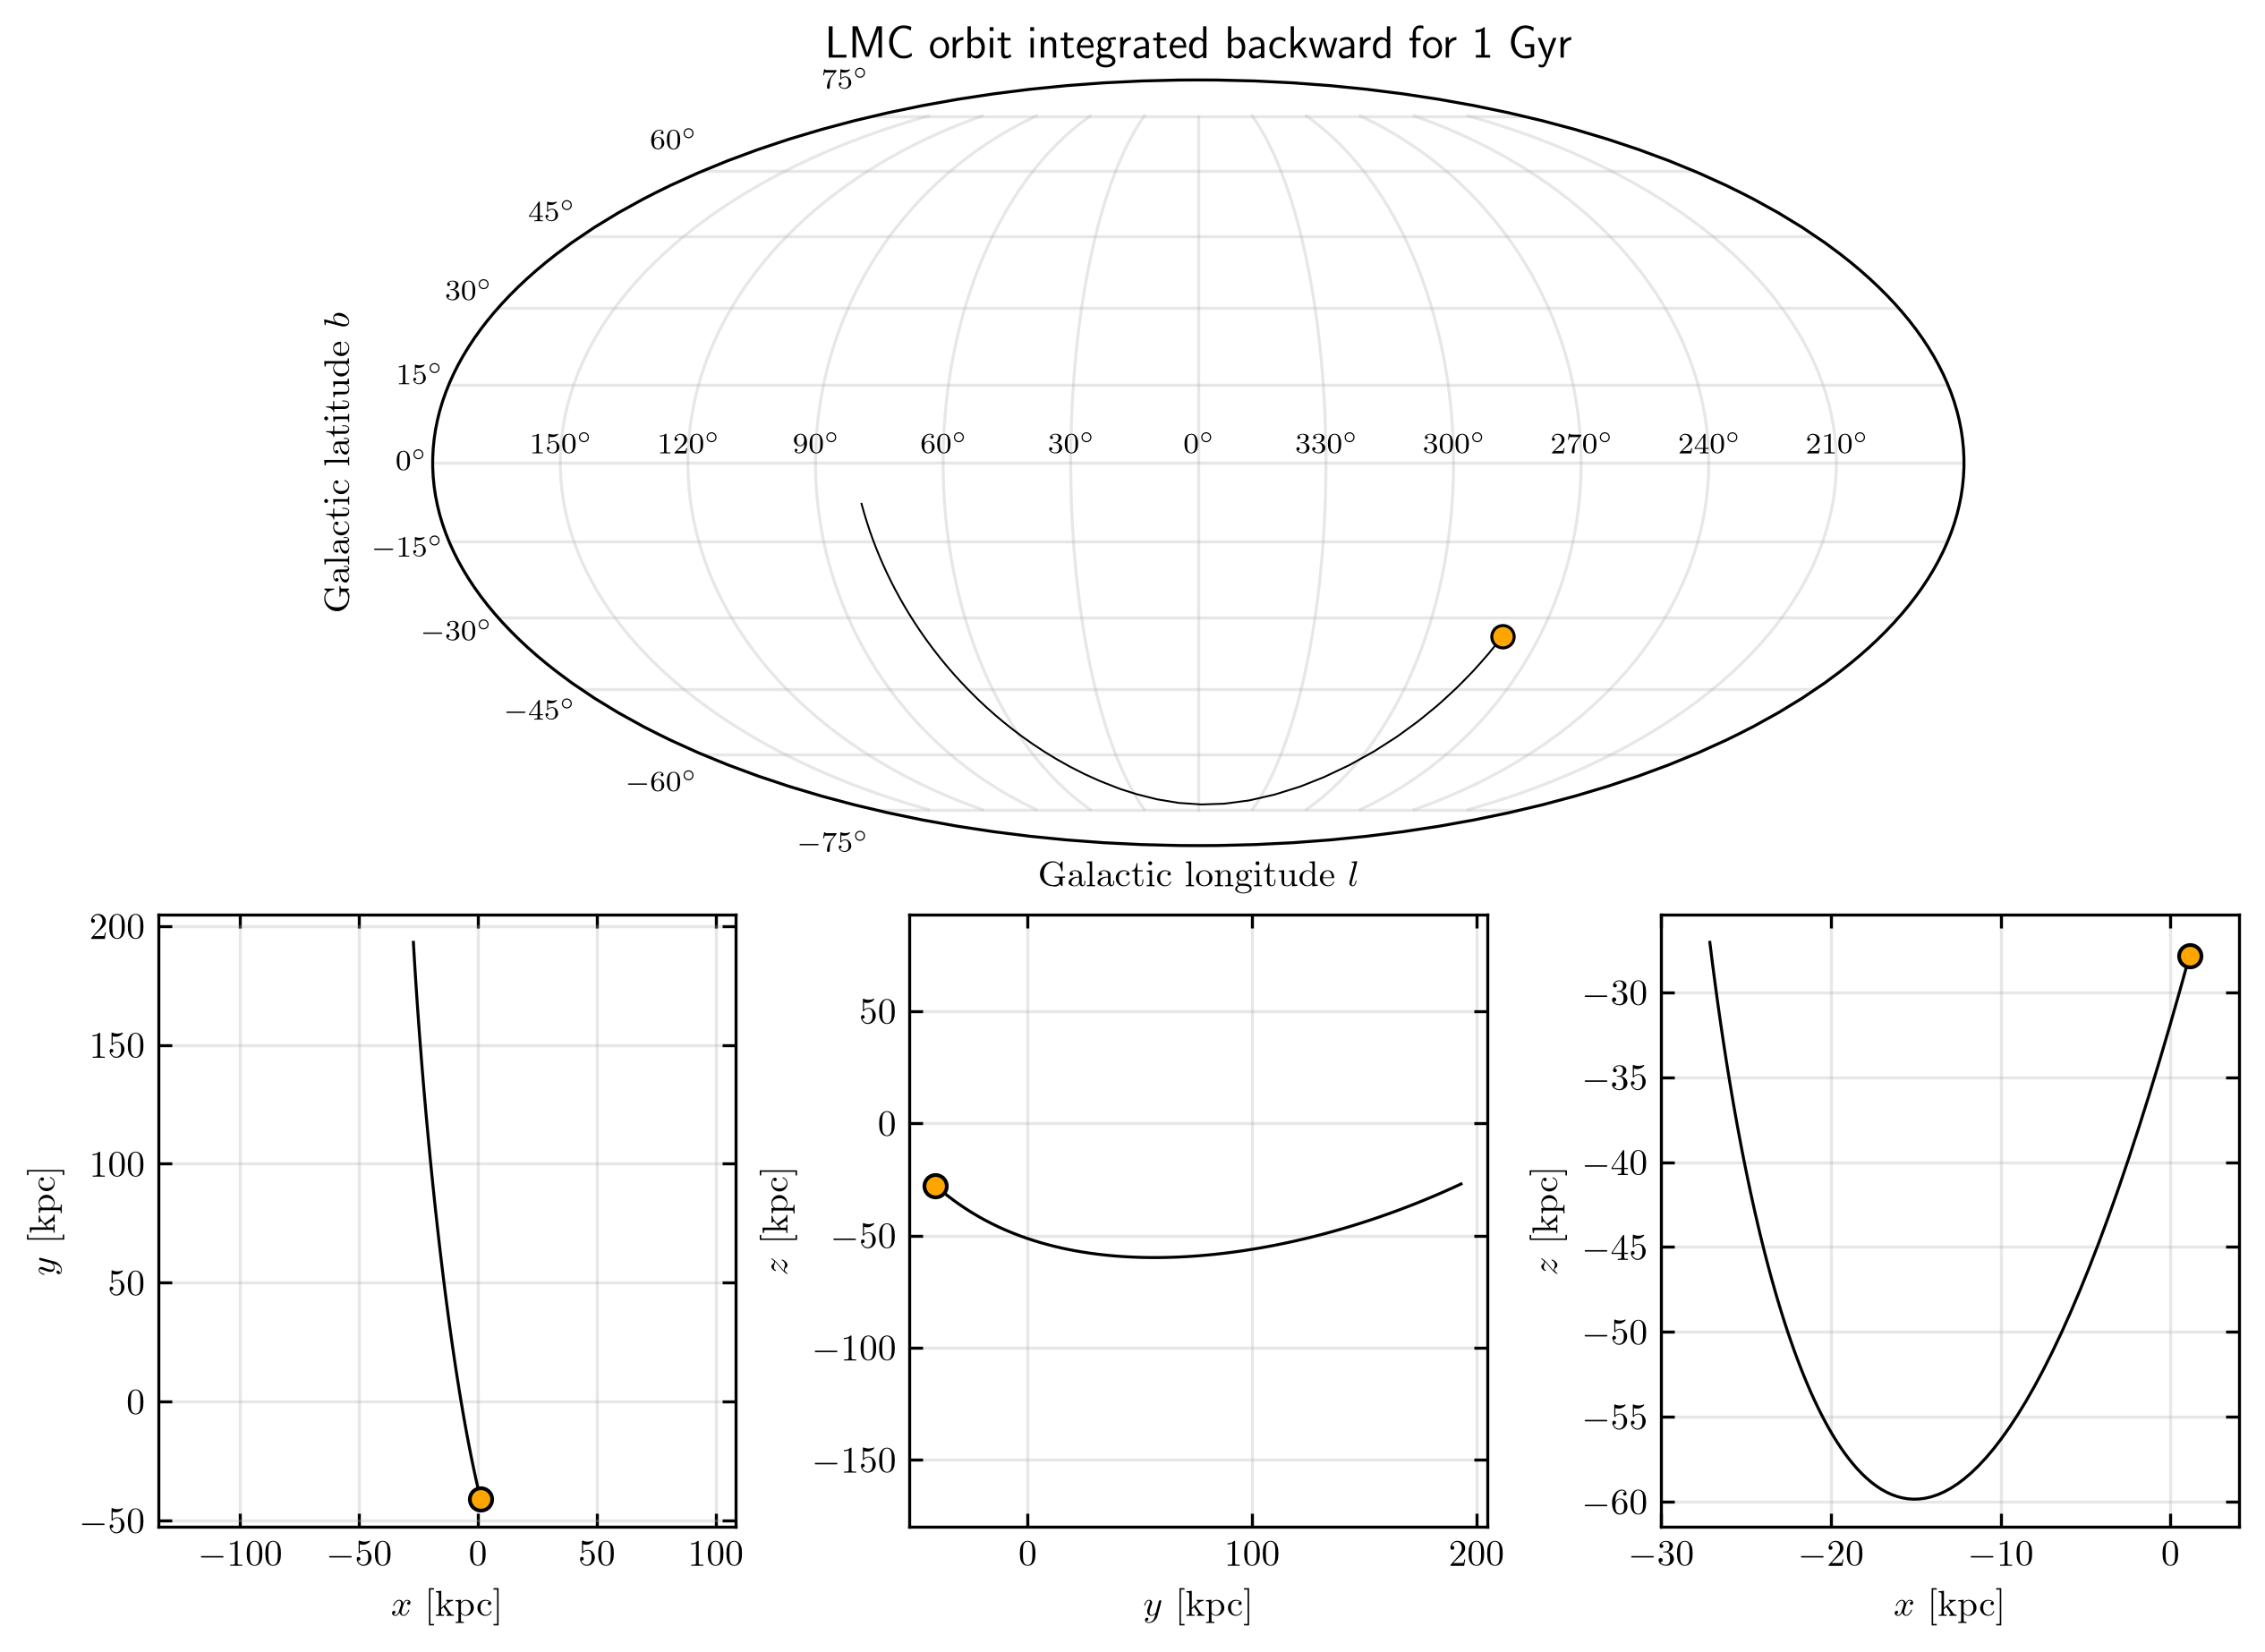

In [7]:
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[1.25, 1],
    hspace=0.1,
    wspace=0.3,
)

# Top row: Mollweide spans all columns
ax_sky = fig.add_subplot(gs[0, :], projection="mollweide")

l_lmc_orbit, b_lmc_orbit = convert_galactic_to_mollweide(
    o_lmc.ll(t_grid, quantity=True),
    o_lmc.bb(t_grid, quantity=True),
)
ax_sky.plot(
    l_lmc_orbit,
    b_lmc_orbit,
    color="black",
    lw=0.5,
    label=r"$\rm integrated\ orbit$",
)

l_lmc_present, b_lmc_present = convert_galactic_to_mollweide(
    o_lmc.ll(0 * u.yr, quantity=True),
    o_lmc.bb(0 * u.yr, quantity=True),
)
ax_sky.scatter(
    l_lmc_present,
    b_lmc_present,
    facecolor="orange",
    edgecolor="black",
    lw=0.8,
    label=r"$\mathrm{LMC\ at\ present}$",
    zorder=2,
)

ax_sky.set_xlabel(r"$\mathrm{Galactic\ longitude}\ l$")
ax_sky.set_ylabel(r"$\mathrm{Galactic\ latitude}\ b$")
ax_sky.grid(True, alpha=0.3)
ax_sky.set_title("LMC orbit integrated backward for 1 Gyr")

ax_sky.set_xticklabels([
    r"$150^\circ$", r"$120^\circ$", r"$90^\circ$",
    r"$60^\circ$", r"$30^\circ$", r"$0^\circ$",
    r"$330^\circ$", r"$300^\circ$", r"$270^\circ$",
    r"$240^\circ$", r"$210^\circ$",
], fontsize=8)

ax_sky.set_yticklabels([
    r"$-75^\circ$", r"$-60^\circ$", r"$-45^\circ$",
    r"$-30^\circ$", r"$-15^\circ$", r"$0^\circ$",
    r"$15^\circ$", r"$30^\circ$", r"$45^\circ$",
    r"$60^\circ$", r"$75^\circ$",
], fontsize=8)

# Bottom row: Cartesian orbit projections
ax_xy = fig.add_subplot(gs[1, 0])
ax_yz = fig.add_subplot(gs[1, 1])
ax_xz = fig.add_subplot(gs[1, 2])

# Adjust these depending on what coordinate object o_lmc returns.
# For gala/orbit-like objects, this often works:
x = o_lmc.x(t_grid, quantity=True).to_value(u.kpc)
y = o_lmc.y(t_grid, quantity=True).to_value(u.kpc)
z = o_lmc.z(t_grid, quantity=True).to_value(u.kpc)

x0 = o_lmc.x(0 * u.yr, quantity=True).to_value(u.kpc)
y0 = o_lmc.y(0 * u.yr, quantity=True).to_value(u.kpc)
z0 = o_lmc.z(0 * u.yr, quantity=True).to_value(u.kpc)

ax_xy.plot(x, y, color="black", lw=0.8)
ax_xy.scatter(x0, y0, facecolor="orange", edgecolor="black", zorder=2)
ax_xy.set_xlabel(r"$x\ \mathrm{[kpc]}$")
ax_xy.set_ylabel(r"$y\ \mathrm{[kpc]}$")

ax_yz.plot(y, z, color="black", lw=0.8)
ax_yz.scatter(y0, z0, facecolor="orange", edgecolor="black", zorder=2)
ax_yz.set_xlabel(r"$y\ \mathrm{[kpc]}$")
ax_yz.set_ylabel(r"$z\ \mathrm{[kpc]}$")

ax_xz.plot(x, z, color="black", lw=0.8)
ax_xz.scatter(x0, z0, facecolor="orange", edgecolor="black", zorder=2)
ax_xz.set_xlabel(r"$x\ \mathrm{[kpc]}$")
ax_xz.set_ylabel(r"$z\ \mathrm{[kpc]}$")

for ax in [ax_xy, ax_yz, ax_xz]:
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

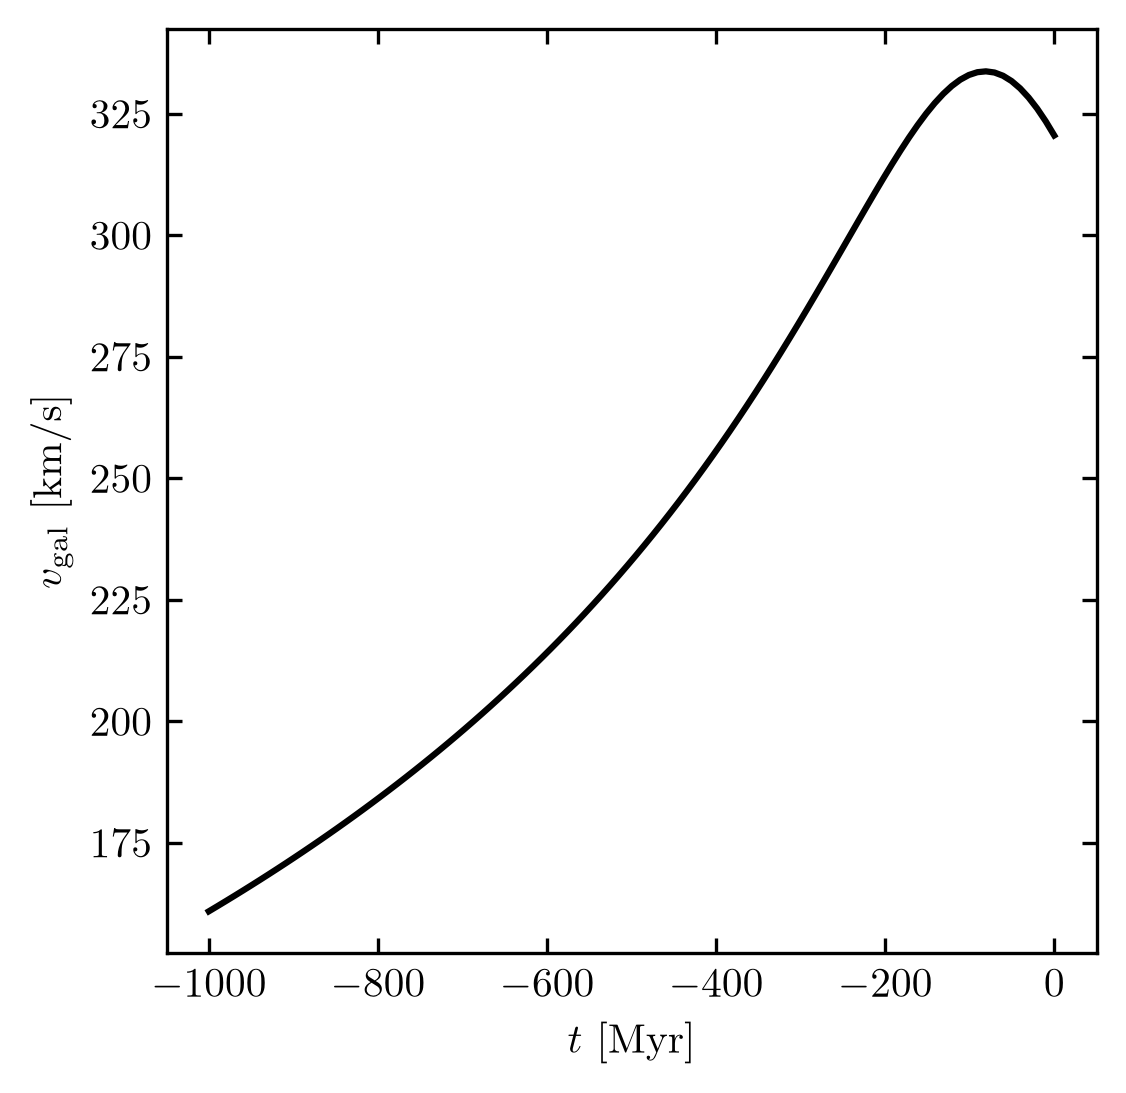

In [10]:
v_gal = np.sqrt(o_lmc.vx(t_grid, quantity=True)**2 + o_lmc.vy(t_grid, quantity=True)**2 + o_lmc.vz(t_grid, quantity=True)**2)
plt.figure(figsize=(4, 4))
plt.plot(t_grid.to_value(u.Myr), v_gal, color='k')
plt.xlabel(r"$t\rm\ [Myr]$")
plt.ylabel(r"$v_{\rm gal}\rm\ [km/s]$")
plt.show()